In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import importlib
import unet
importlib.reload(unet)
from unet import build_unet
from unet import load_preprocess
from mobile_u_net import load_preprocess_mobilenet
from mobile_u_net import build_mobile_u_net
from mobile_u_net import flip
from mobile_u_net import sparse_categorical_focal_loss

In [3]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

I0000 00:00:1777582542.637228 25373871 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777582542.637394 25373871 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
dataset = dataset.map(load_preprocess_mobilenet)

In [5]:
batch_size = 8
train_ds = dataset.take(160)
val_ds = dataset.skip(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)
flipped_train_ds = train_ds.map(flip)
train_ds = train_ds.concatenate(flipped_train_ds).shuffle(320).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [6]:
model = build_mobile_u_net((128,384, 3), 20)
model.summary()

/Users/kuzeyaldemir/Projects/drive-vision/mobile_u_net.py:100: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobile_net = tf.keras.applications.MobileNetV2(


Model: "mobile_u_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobile_net          │ [(None, 64, 192,  │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 96, 144), (None,  │            │                   │
│                     │ 16, 48, 192),     │            │                   │
│                     │ (None, 8, 24,     │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 12, 1280)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 24,     │  2,621,952 │ mobile_net[0][4]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 24,     │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1088)             │            │ mobile_net[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 24,     │  5,014,016 │ concatenate[0][0] │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 24,     │  2,359,808 │ conv2d[0][0]      │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 48,    │    524,544 │ conv2d_1[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 48,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 448)              │            │ mobile_net[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 48,    │  1,032,448 │ concatenate_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 48,    │    590,080 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 96,    │    131,200 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 96,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 272)              │            │ mobile_net[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 96,    │    313,472 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 96,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 192,   │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                 

 Total params: 15,199,892 (57.98 MB)

 Trainable params: 12,941,908 (49.37 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_categorical_focal_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=20, sparse_y_pred=False, ignore_class=19, name='miou')
    ]
)

In [8]:
experiment_name = 'mobilenet_frozen_skip_flip_focal_gamma2_lr0.001'

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir=f'logs/{experiment_name}'),
               tf.keras.callbacks.ModelCheckpoint(
                   f'checkpoints/{experiment_name}_best.keras',
                   save_best_only=True,
                   monitor='val_miou',
                   mode='max',
               )]
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 293ms/step - accuracy: 0.4009 - loss: 1.5703 - miou: 0.0447 - val_accuracy: 0.5888 - val_loss: 1.0942 - val_miou: 0.0920
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 260ms/step - accuracy: 0.6466 - loss: 0.8111 - miou: 0.1264 - val_accuracy: 0.6648 - val_loss: 0.7880 - val_miou: 0.1393
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.7140 - loss: 0.6440 - miou: 0.1703 - val_accuracy: 0.7526 - val_loss: 0.6414 - val_miou: 0.2009
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step - accuracy: 0.7847 - loss: 0.4971 - miou: 0.2156 - val_accuracy: 0.7633 - val_loss: 0.6011 - val_miou: 0.2065
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step - accuracy: 0.8045 - loss: 0.4323 - miou: 0.2313 - val_accuracy: 0.7766 - val_loss: 0.5503 - val_miou: 0.2195
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 263ms/step - accuracy: 0.8107 - loss: 0.4162 - miou: 0.2354 - val_accuracy: 0.7878 - val_loss: 0.5278 - val_miou: 0.2213
Epoch 7/20
40/40 ━━━━━

In [9]:
model = tf.keras.models.load_model('checkpoints/mobilenet_frozen_skip_flip_focal_gamma2_lr0.001_best.keras')
experiment_name = 'mobilenet_finetuned_skip_flip_focal_gamma2_lr1e-4'

model.get_layer('mobile_net').trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=sparse_categorical_focal_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=20, sparse_y_pred=False, ignore_class=19, name='miou')
    ]
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir=f'logs/{experiment_name}'),
               tf.keras.callbacks.ModelCheckpoint(
                   f'checkpoints/{experiment_name}_best.keras',
                   save_best_only=True,
                   monitor='val_miou',
                   mode='max',
               )]
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 0.8931 - loss: 0.1906 - miou: 0.3760 - val_accuracy: 0.8115 - val_loss: 0.4430 - val_miou: 0.2644
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 357ms/step - accuracy: 0.8995 - loss: 0.1766 - miou: 0.4183 - val_accuracy: 0.8105 - val_loss: 0.4533 - val_miou: 0.2638
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 405ms/step - accuracy: 0.9027 - loss: 0.1702 - miou: 0.4285 - val_accuracy: 0.8146 - val_loss: 0.4531 - val_miou: 0.2668
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 349ms/step - accuracy: 0.9044 - loss: 0.1659 - miou: 0.4377 - val_accuracy: 0.8127 - val_loss: 0.4593 - val_miou: 0.2642
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 366ms/step - accuracy: 0.9070 - loss: 0.1613 - miou: 0.4478 - val_accuracy: 0.8142 - val_loss: 0.4667 - val_miou: 0.2668
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 360ms/step - accuracy: 0.9090 - loss: 0.1569 - miou: 0.4508 - val_accuracy: 0.8119 - val_loss: 0.4903 - val_miou: 0.2637
Epoch 7/10
40/40 ━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


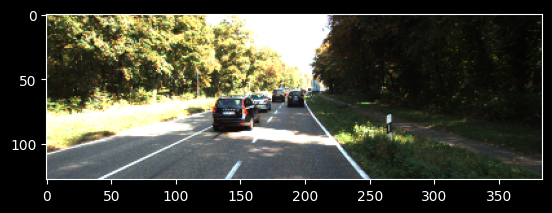

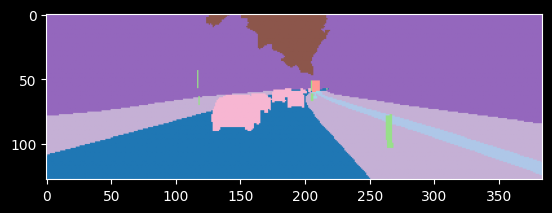

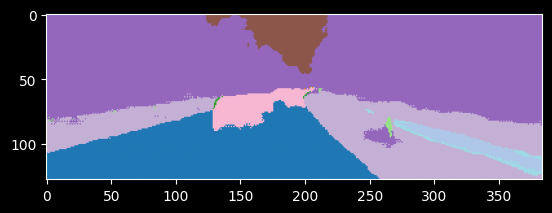

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


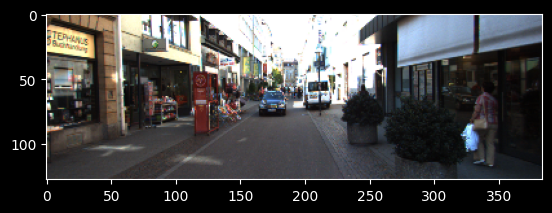

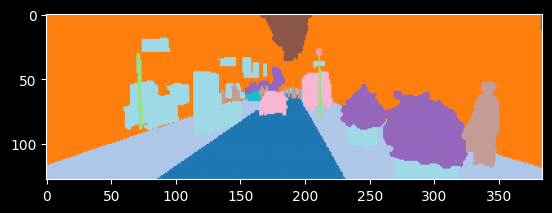

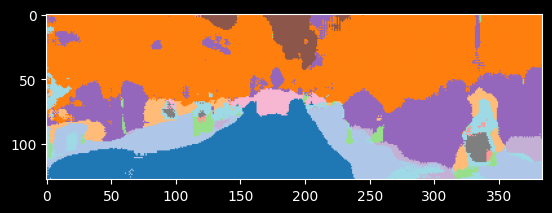

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


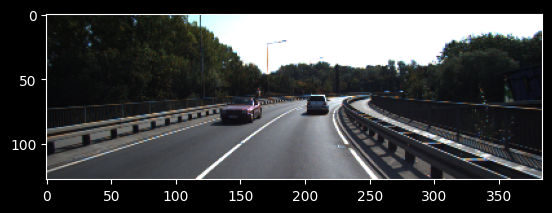

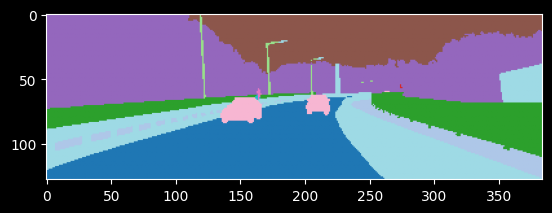

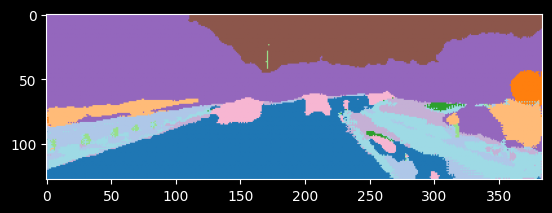

In [10]:
for image, mask in val_ds.take(3):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)

    plt.imshow((image[0]+1)/2)
    plt.show()
    plt.imshow(tf.squeeze(mask[0]), cmap='tab20', vmin=0, vmax=19)
    plt.show()
    plt.imshow(predicted_mask[0], cmap='tab20', vmin=0, vmax=19)
    plt.show()